In [23]:
import pandas as pd
from pathlib import Path

ruta_base = Path(r"ETAPA 6 - COMPARACIONES IMP\data 2018\GEIH")

nombre_ft  = "Cabecera - Fuerza de trabajo.csv"
nombre_oc  = "Cabecera - Ocupados.csv"
nombre_des = "Cabecera - Desocupados.csv"
nombre_edu = "Cabecera - Características generales (Personas).csv"

archivos_ft, archivos_oc, archivos_des, archivos_edu = [], [], [], []

for carpeta_mes in ruta_base.iterdir():
    if carpeta_mes.is_dir():
        if (carpeta_mes / nombre_ft).exists():
            archivos_ft.append(carpeta_mes / nombre_ft)
        if (carpeta_mes / nombre_oc).exists():
            archivos_oc.append(carpeta_mes / nombre_oc)
        if (carpeta_mes / nombre_des).exists():
            archivos_des.append(carpeta_mes / nombre_des)
        if (carpeta_mes / nombre_edu).exists():
            archivos_edu.append(carpeta_mes / nombre_edu)

print(len(archivos_ft), len(archivos_oc), len(archivos_des), len(archivos_edu))

11 12 12 9


In [11]:
def leer_y_unir(lista_archivos):
    dfs = []

    for archivo in lista_archivos:
        df = pd.read_csv(
            archivo,
            sep=";",
            encoding="latin1",
            low_memory=False
        )
        df.columns = [c.strip().replace("\ufeff", "") for c in df.columns]
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [24]:
def leer_y_unir(lista_archivos):
    dfs = []
    for archivo in lista_archivos:
        df = pd.read_csv(
            archivo,
            sep=";",
            encoding="latin1",
            low_memory=False
        )
        df.columns = [c.strip().replace("\ufeff", "") for c in df.columns]
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [25]:
geih_ft = leer_y_unir(archivos_ft)
geih_oc = leer_y_unir(archivos_oc)
geih_des = leer_y_unir(archivos_des)
geih_edu = leer_y_unir(archivos_edu)

In [26]:
mapa_ciudades = {
    "63": "Armenia",
    "66": "Pereira",
    "76": "Cali"
}

for df in [geih_ft, geih_oc, geih_des, geih_edu]:
    df["DPTO"] = df["DPTO"].astype(str).str.zfill(2)
    df["CIUDAD"] = df["DPTO"].map(mapa_ciudades)

geih_ft = geih_ft[geih_ft["CIUDAD"].notna()]
geih_oc = geih_oc[geih_oc["CIUDAD"].notna()]
geih_des = geih_des[geih_des["CIUDAD"].notna()]
geih_edu = geih_edu[geih_edu["CIUDAD"].notna()]

In [27]:
for df in [geih_ft, geih_oc, geih_des, geih_edu]:
    df["fex_c_2011"] = (
        df["fex_c_2011"]
        .astype(str)
        .str.strip()
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df["fex_c_2011"] = pd.to_numeric(df["fex_c_2011"], errors="coerce")

In [28]:
ocupados = geih_oc.groupby("CIUDAD")["fex_c_2011"].sum()
desocupados = geih_des.groupby("CIUDAD")["fex_c_2011"].sum()
fuerza = geih_ft.groupby("CIUDAD")["fex_c_2011"].sum()

geih_laboral = pd.DataFrame({
    "CIUDAD": ocupados.index,
    "OCUPADOS": ocupados.values,
    "DESEMPLEADOS": desocupados.values,
    "FUERZA": fuerza.values
})

geih_laboral["TASA_OCUPACION_GEIH"] = geih_laboral["OCUPADOS"] / geih_laboral["FUERZA"]
geih_laboral["TASA_DESEMPLEO_GEIH"] = geih_laboral["DESEMPLEADOS"] / geih_laboral["FUERZA"]

geih_laboral = geih_laboral.round(4)

display(geih_laboral)

,CIUDAD,OCUPADOS,DESEMPLEADOS,FUERZA,TASA_OCUPACION_GEIH,TASA_DESEMPLEO_GEIH
0,Armenia,3.584910e+06,6.069654e+05,5.650052e+06,0.6345,0.1074
1,Cali,2.201596e+07,3.068530e+06,3.490554e+07,0.6307,0.0879
2,Pereira,4.826810e+06,4.488737e+05,7.487081e+06,0.6447,0.0600


In [29]:
print(geih_edu.columns.tolist())

['ï»¿DIRECTORIO', 'SECUENCIA_P', 'ORDEN', 'HOGAR', 'REGIS', 'P6016', 'P6020', 'P6030S1', 'P6030S3', 'P6040', 'P6050', 'P6070', 'P6081', 'P6081S1', 'P6083', 'P6083S1', 'P6071', 'P6071S1', 'P6090', 'P6140', 'P6150', 'P6100', 'P6110', 'P6120', 'P6125', 'P6160', 'P6170', 'P6175', 'P6210', 'P6210S1', 'P6220', 'P6269', 'CLASE', 'ESC', 'MES', 'DPTO', 'fex_c_2011', 'AREA', 'CIUDAD']


In [30]:
cols_edu = ["P6160", "P6170", "P6175", "P6210", "P6220", "P6269", "fex_c_2011", "CIUDAD"]

display(geih_edu[cols_edu].head())

for col in ["P6160", "P6170", "P6175", "P6210", "P6220", "P6269"]:
    print(f"\n========== {col} ==========")
    print(geih_edu[col].value_counts(dropna=False).head(20))

,P6160,P6170,P6175,P6210,P6220,P6269,fex_c_2011,CIUDAD
3814,1,2,,6,3,,117.887464,Armenia
3815,1,2,,5,2,,117.887464,Armenia
3816,1,2,,6,3,,117.887464,Armenia
3817,1,2,,6,3,,117.887464,Armenia
3818,1,1,1,4,,,117.887464,Armenia



========== P6160 ==========
P6160
1    59109
2     4391
      2107
Name: count, dtype: int64

========== P6170 ==========
P6170
2    48148
1    15352
      2107
Name: count, dtype: int64

========== P6175 ==========
P6175
     50255
1    10855
2     4497
Name: count, dtype: int64

========== P6210 ==========
P6210
5    16555
3    15807
6    14948
4    12028
1     2811
      2107
2     1343
9        8
Name: count, dtype: int64

========== P6220 ==========
P6220
     34104
2    18645
3     5574
4     4140
1     1638
5     1505
9        1
Name: count, dtype: int64

========== P6269 ==========
P6269
     61846
2     3693
1       68
Name: count, dtype: int64


In [31]:
import pandas as pd
import numpy as np

# =========================
# 7. EDUCACIÓN GEIH
# =========================
# IMPORTANTE:
# Ajusta estas dos columnas después de ver los value_counts del chunk anterior.
# La idea es:
# - col_asistencia: variable tipo sí/no de asistencia
# - col_escolaridad: variable numérica u ordinal de nivel/años de estudio

col_asistencia = "P6170"
col_escolaridad = "P6220"

# Convertir a numérico
for col in [col_asistencia, col_escolaridad]:
    geih_edu[col] = pd.to_numeric(geih_edu[col], errors="coerce")

# =========================
# 7.1 Asistencia
# =========================
# OJO:
# Esto asume que en col_asistencia el valor 1 = sí.
# Si al revisar frecuencias ves otro código, lo cambias.
geih_edu["asiste_bin"] = np.where(geih_edu[col_asistencia] == 1, 1, 0)

# =========================
# 7.2 Escolaridad
# =========================
# Se usa directamente la variable elegida como aproximación de escolaridad/nivel educativo
geih_edu["escolaridad_val"] = geih_edu[col_escolaridad]

edu_ciudad = geih_edu.groupby("CIUDAD").apply(
    lambda x: pd.Series({
        "ASISTENCIA_GEIH": np.average(x["asiste_bin"], weights=x["fex_c_2011"]),
        "ESCOLARIDAD_GEIH": np.average(
            x["escolaridad_val"].dropna(),
            weights=x.loc[x["escolaridad_val"].notna(), "fex_c_2011"]
        ) if x["escolaridad_val"].notna().sum() > 0 else np.nan
    })
).reset_index()

edu_ciudad = edu_ciudad.round(4)

display(edu_ciudad)

,CIUDAD,ASISTENCIA_GEIH,ESCOLARIDAD_GEIH
0,Armenia,0.2659,2.4889
1,Cali,0.2605,2.4314
2,Pereira,0.2557,2.5495


In [33]:
import pandas as pd
from pathlib import Path

# =========================
# 0. RUTAS DE LOS ARCHIVOS CLUSTER EXTRA
# =========================
base_clusters = Path(r"ETAPA 4 - CLUSTERING\outputs")

ruta_armenia = base_clusters / "armenia_clusters_final_extra.csv"
ruta_cali = base_clusters / "cali_clusters_final_extra.csv"
ruta_pereira = base_clusters / "pereira_clusters_final_extra.csv"

print(ruta_armenia)
print(ruta_cali)
print(ruta_pereira)

# Verificación rápida
print("Armenia existe:", ruta_armenia.exists())
print("Cali existe:", ruta_cali.exists())
print("Pereira existe:", ruta_pereira.exists())

ETAPA 4 - CLUSTERING\outputs\armenia_clusters_final_extra.csv
ETAPA 4 - CLUSTERING\outputs\cali_clusters_final_extra.csv
ETAPA 4 - CLUSTERING\outputs\pereira_clusters_final_extra.csv
Armenia existe: True
Cali existe: True
Pereira existe: True


In [34]:
def resumen_clusters(ruta_csv, ciudad):
    df = pd.read_csv(ruta_csv, encoding="utf-8-sig")
    df.columns = [c.strip().replace("\ufeff", "") for c in df.columns]

    df_manz = df.groupby("COD_DANE_ANM", as_index=False).first()

    for col in ["pct_trabaja", "pct_asistencia", "P_NIVEL_ANOSR"]:
        df_manz[col] = pd.to_numeric(df_manz[col], errors="coerce")

    return {
        "CIUDAD": ciudad,
        "LAB_CIUDAD": (df_manz["pct_trabaja"] / 100).mean(),
        "ASISTENCIA_CLUSTER": (df_manz["pct_asistencia"] / 100).mean(),
        "ESCOLARIDAD_CLUSTER": df_manz["P_NIVEL_ANOSR"].mean()
    }

clusters_total = pd.DataFrame([
    resumen_clusters(ruta_armenia, "Armenia"),
    resumen_clusters(ruta_cali, "Cali"),
    resumen_clusters(ruta_pereira, "Pereira")
]).round(4)

display(clusters_total)

,CIUDAD,LAB_CIUDAD,ASISTENCIA_CLUSTER,ESCOLARIDAD_CLUSTER
0,Armenia,0.3985,0.2314,6.0080
1,Cali,0.4487,0.2356,6.5482
2,Pereira,0.4316,0.2533,5.7382


In [37]:
# Unir resultados laborales y educativos de GEIH
geih_total = geih_laboral.merge(
    edu_ciudad,
    on="CIUDAD",
    how="left"
).round(4)

display(geih_total)

,CIUDAD,OCUPADOS,DESEMPLEADOS,FUERZA,TASA_OCUPACION_GEIH,TASA_DESEMPLEO_GEIH,ASISTENCIA_GEIH,ESCOLARIDAD_GEIH
0,Armenia,3.584910e+06,6.069654e+05,5.650052e+06,0.6345,0.1074,0.2659,2.4889
1,Cali,2.201596e+07,3.068530e+06,3.490554e+07,0.6307,0.0879,0.2605,2.4314
2,Pereira,4.826810e+06,4.488737e+05,7.487081e+06,0.6447,0.0600,0.2557,2.5495


In [49]:
comparacion_total = clusters_total.merge(
    geih_total,
    on="CIUDAD",
    how="left"
).round(4)

display(comparacion_total)

,CIUDAD,LAB_CIUDAD,ASISTENCIA_CLUSTER,ESCOLARIDAD_CLUSTER,OCUPADOS,DESEMPLEADOS,FUERZA,TASA_OCUPACION_GEIH,TASA_DESEMPLEO_GEIH,ASISTENCIA_GEIH,ESCOLARIDAD_GEIH
0,Armenia,0.3985,0.2314,6.0080,3.584910e+06,6.069654e+05,5.650052e+06,0.6345,0.1074,0.2659,2.4889
1,Cali,0.4487,0.2356,6.5482,2.201596e+07,3.068530e+06,3.490554e+07,0.6307,0.0879,0.2605,2.4314
2,Pereira,0.4316,0.2533,5.7382,4.826810e+06,4.488737e+05,7.487081e+06,0.6447,0.0600,0.2557,2.5495


In [50]:
# =========================
# NORMALIZACIÓN ESCOLARIDAD
# =========================
comparacion_total["ESCOLARIDAD_GEIH_NORM"] = (
    comparacion_total["ESCOLARIDAD_GEIH"] / comparacion_total["ESCOLARIDAD_GEIH"].max()
)

comparacion_total["ESCOLARIDAD_CLUSTER_NORM"] = (
    comparacion_total["ESCOLARIDAD_CLUSTER"] / comparacion_total["ESCOLARIDAD_CLUSTER"].max()
)

In [51]:
comparacion_total["DIF_LAB"] = (
    comparacion_total["LAB_CIUDAD"] - comparacion_total["TASA_OCUPACION_GEIH"]
)

comparacion_total["DIF_ASISTENCIA"] = (
    comparacion_total["ASISTENCIA_CLUSTER"] - comparacion_total["ASISTENCIA_GEIH"]
)

comparacion_total["DIF_ESCOLARIDAD"] = (
    comparacion_total["ESCOLARIDAD_CLUSTER"] - comparacion_total["ESCOLARIDAD_GEIH"]
)

comparacion_total = comparacion_total.round(4)

display(comparacion_total)

,CIUDAD,LAB_CIUDAD,ASISTENCIA_CLUSTER,ESCOLARIDAD_CLUSTER,OCUPADOS,DESEMPLEADOS,FUERZA,TASA_OCUPACION_GEIH,TASA_DESEMPLEO_GEIH,ASISTENCIA_GEIH,ESCOLARIDAD_GEIH,ESCOLARIDAD_GEIH_NORM,ESCOLARIDAD_CLUSTER_NORM,DIF_LAB,DIF_ASISTENCIA,DIF_ESCOLARIDAD
0,Armenia,0.3985,0.2314,6.0080,3.584910e+06,6.069654e+05,5.650052e+06,0.6345,0.1074,0.2659,2.4889,0.9762,0.9175,-0.2360,-0.0345,3.5191
1,Cali,0.4487,0.2356,6.5482,2.201596e+07,3.068530e+06,3.490554e+07,0.6307,0.0879,0.2605,2.4314,0.9537,1.0000,-0.1820,-0.0249,4.1168
2,Pereira,0.4316,0.2533,5.7382,4.826810e+06,4.488737e+05,7.487081e+06,0.6447,0.0600,0.2557,2.5495,1.0000,0.8763,-0.2131,-0.0024,3.1887


In [52]:
tabla_final_geih = comparacion_total[[
    "CIUDAD",
    "LAB_CIUDAD",
    "TASA_OCUPACION_GEIH",
    "DIF_LAB",
    "ASISTENCIA_CLUSTER",
    "ASISTENCIA_GEIH",
    "DIF_ASISTENCIA",
    "ESCOLARIDAD_CLUSTER",
    "ESCOLARIDAD_GEIH",
    "DIF_ESCOLARIDAD"
]].copy()

display(tabla_final_geih)

,CIUDAD,LAB_CIUDAD,TASA_OCUPACION_GEIH,DIF_LAB,ASISTENCIA_CLUSTER,ASISTENCIA_GEIH,DIF_ASISTENCIA,ESCOLARIDAD_CLUSTER,ESCOLARIDAD_GEIH,DIF_ESCOLARIDAD
0,Armenia,0.3985,0.6345,-0.2360,0.2314,0.2659,-0.0345,6.0080,2.4889,3.5191
1,Cali,0.4487,0.6307,-0.1820,0.2356,0.2605,-0.0249,6.5482,2.4314,4.1168
2,Pereira,0.4316,0.6447,-0.2131,0.2533,0.2557,-0.0024,5.7382,2.5495,3.1887


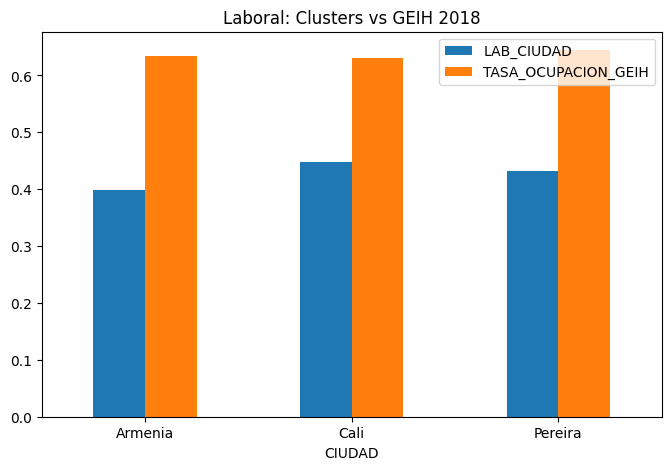

In [53]:
import matplotlib.pyplot as plt

df_plot_lab = tabla_final_geih.set_index("CIUDAD")[[
    "LAB_CIUDAD", "TASA_OCUPACION_GEIH"
]]

df_plot_lab.plot(kind="bar", figsize=(8,5))
plt.title("Laboral: Clusters vs GEIH 2018")
plt.xticks(rotation=0)
plt.show()

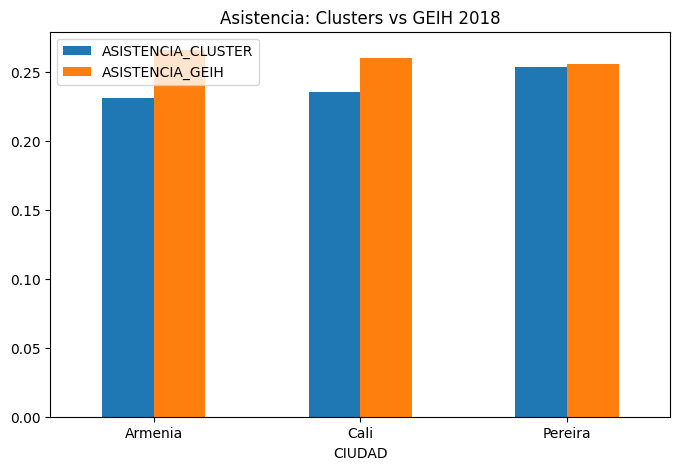

In [54]:
df_plot_edu = tabla_final_geih.set_index("CIUDAD")[[
    "ASISTENCIA_CLUSTER", "ASISTENCIA_GEIH"
]]

df_plot_edu.plot(kind="bar", figsize=(8,5))
plt.title("Asistencia: Clusters vs GEIH 2018")
plt.xticks(rotation=0)
plt.show()

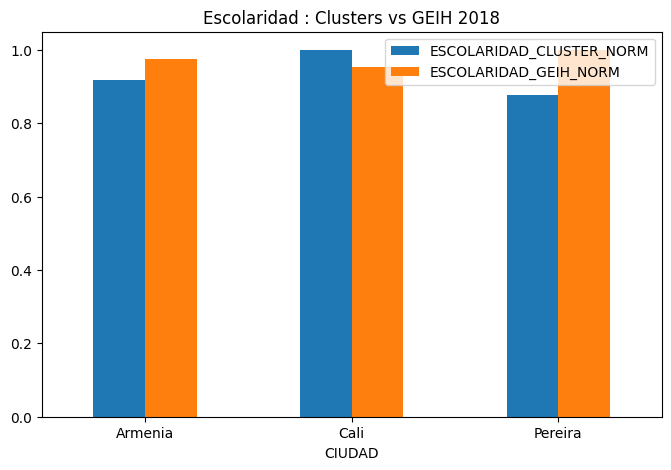

In [59]:
df_plot_esc = comparacion_total.set_index("CIUDAD")[[
    "ESCOLARIDAD_CLUSTER_NORM", "ESCOLARIDAD_GEIH_NORM"
]]

df_plot_esc.plot(kind="bar", figsize=(8,5))
plt.title("Escolaridad : Clusters vs GEIH 2018")
plt.xticks(rotation=0)
plt.show()